In [1]:
import sys
sys.path.append("..")

from copy import deepcopy
import pickle
import time
from itertools import product
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import numpy as np
import pandas as pd
import torch
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import shap
from mlresearch.datasets import BinaryDatasets, ContinuousCategoricalDatasets
from tabpfn import TabPFNRegressor
from explainerpfn.base import ExplainerPFN
from explainerpfn.train import SyntheticDataGenerator
from explainerpfn.train._activations import identity

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
    # Total and free memory in bytes
    free, total = torch.cuda.mem_get_info()
    print(f"Total memory: {total / 1024**2:.2f}MB")
    print(f"Free memory: {free / 1024**2:.2f}MB")
else:
    print("No GPU available. Training will run on CPU.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random_state = 42
max_samples = 20000
max_features = 15
model_path = "../../explainerpfn_model_NOV_15.ckp"

No GPU available. Training will run on CPU.


# Collect datasets

In [2]:
datasets = BinaryDatasets().download()
datasets.content_ += ContinuousCategoricalDatasets().download().content_
content_processed = []
for name, df in datasets:
    # Drop Credit Approval dataset due to weird formatting issues
    if name == "CREDIT APPROVAL":
        continue

    df.columns = df.columns.astype(str)
    df = df.loc[:, ~df.columns.str.startswith("cat")].copy()
    if df.target.nunique() > 2:
        df.target = (df.target == df.target.mode().iloc[0]).astype(int)
    
    if df.shape[1] < max_features and df.shape[1] > 2 and df.shape[0] < max_samples:
        content_processed.append((name, df))

datasets.content_ = content_processed
summary = datasets.summarize_datasets().sort_values(by="Observations")
summary

Datasets:   0%|          | 0/7 [00:00<?, ?it/s]

Datasets:   0%|          | 0/16 [00:00<?, ?it/s]

,Features,Observations,Minority Obs.,Majority Obs.,Imbalance Ratio,Classes
Dataset name,,,,,,
ECHOCARDIOGRAM,8,61,17,44,2.59,2
HEPATITIS,4,129,24,105,4.38,2
FLAGS,10,194,60,134,2.23,2
HEART,6,270,120,150,1.25,2
HEART DISEASE,5,740,357,383,1.07,2
ANNEALING,6,798,190,608,3.20,2
GERMAN CREDIT,7,1000,300,700,2.33,2
BANKNOTE AUTHENTICATION,4,1372,610,762,1.25,2
CONTRACEPTIVE,5,1473,629,844,1.34,2


In [3]:
summary_exp = summary.copy()
summary_exp.drop(columns=["Classes"], inplace=True)
summary_exp["Maj/Min Obs."] = summary_exp["Majority Obs."].astype(str) +  "/" + summary_exp["Minority Obs."].astype(str)
summary_exp = summary_exp[["Observations", "Features", "Maj/Min Obs.", "Imbalance Ratio"]]
name_mapping = {
    "Banknote Authentication": "(BA)", 
    "Abalone": "(AB)",
    "Annealing": "(AN)",
    "Contraceptive": "(CC)", 
    "Echocardiogram": "(EC)", 
    "Flags": "(FL)", 
    "German Credit": "(GC)", 
    "Heart": "(HE)", 
    "Heart Disease": "(HD)", 
    "Hepatitis": "(HP)", 
    "Thyroid": "(TH)"
}
summary_exp.index = summary_exp.index.str.title().map(lambda x: f"{x} {name_mapping[x]}")
summary_exp.to_latex("datasets_summary.tex")
summary_exp

,Observations,Features,Maj/Min Obs.,Imbalance Ratio
Dataset name,,,,
Echocardiogram (EC),61,8,44/17,2.59
Hepatitis (HP),129,4,105/24,4.38
Flags (FL),194,10,134/60,2.23
Heart (HE),270,6,150/120,1.25
Heart Disease (HD),740,5,383/357,1.07
Annealing (AN),798,6,608/190,3.20
German Credit (GC),1000,7,700/300,2.33
Banknote Authentication (BA),1372,4,762/610,1.25
Contraceptive (CC),1473,5,844/629,1.34


# Collect explanations

In [2]:
def few_shot_explanations(X_train, y_train, base_model, shap_explanations, X_test, y_test, model, n_samples=5, random_state=42):
        
    X_train_sample, _, y_train_sample, _ = train_test_split(
        X_train, y_train,
        train_size=n_samples, 
        random_state=random_state
    )
    explanations_sample = shap_explanations(base_model.named_steps["scaler"].transform(X_train_sample)).values[:, :, -1]
    
    Xy_sample = np.concatenate([X_train_sample, y_train_sample.reshape(-1, 1)], axis=1)
    Xy_test = np.concatenate([X_test, y_test.reshape(-1, 1)], axis=1) 

    tabpfn_preds = np.zeros(X_test.shape, dtype=float)
    for i in range(X_test.shape[1] - 1): 
        exp_target = explanations_sample[:, i]

        model.fit(Xy_sample, exp_target)

        pred = model.predict(Xy_test)
        tabpfn_preds[:, i] = pred

    return tabpfn_preds


In [3]:
def run_experiments_across_datasets(datasets, model_path, base_model, few_shot_sample_size, few_shot_predictors, random_state=42):
    results = {}

    for dataset_name, df in tqdm(datasets):

        results[dataset_name] = {}
        X = df.drop(columns=["target"]).values
        y = df["target"].values

        # Train a model and get predictions
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_state)
        base_model_ = clone(base_model)
        base_model_.fit(X_train, y_train)
        y_train_scores = base_model_.predict_proba(X_train)[:, 1]
        y_test_scores = base_model_.predict_proba(X_test)[:, 1]
        results[dataset_name]["X_train"] = X_train
        results[dataset_name]["X_test"] = X_test
        results[dataset_name]["y_train"] = y_train
        results[dataset_name]["y_test"] = y_test
        results[dataset_name]["base_model"] = base_model_
        results[dataset_name]["y_train_scores"] = y_train_scores
        results[dataset_name]["y_test_scores"] = y_test_scores

        start_time = time.time()
        shap_explanations = shap.explainers.Exact(base_model_.steps[-1][1].predict_proba, base_model_.named_steps["scaler"].transform(X_train))
        shap_values_test = shap_explanations(base_model_.named_steps["scaler"].transform(X_test)).values[:, :, -1]
        end_time = time.time()
        results[dataset_name]["shap"] = shap_values_test
        results[dataset_name]["shap_time"] = end_time - start_time

        start_time = time.time()
        xai = ExplainerPFN(model_path=model_path, random_state=random_state, device=device)
        xai.fit(np.concatenate([X_train, X_test], axis=0), np.concatenate([y_train_scores, y_test_scores], axis=0))
        exp_pfn_values = xai.predict(X_test, y_test_scores)
        end_time = time.time()
        results[dataset_name]["explainerpfn_time"] = end_time - start_time
        results[dataset_name]["explainerpfn"] = exp_pfn_values / np.sqrt(X.shape[1])  # Normalize by number of features
        results[dataset_name]["explainerpfn_statistical+additive"] = xai.apply_correction(y_test_scores, exp_pfn_values, kind=["statistical", "additive"])
        results[dataset_name]["explainerpfn_additive"] = xai.apply_correction(y_test_scores, exp_pfn_values - exp_pfn_values.mean(axis=0), kind=["additive"])

        for n_samples, (model_name, model) in product(few_shot_sample_size, few_shot_predictors.items()):
            model = clone(model)
            start_time = time.time()
            exp_few_shot = few_shot_explanations(X_train, y_train, base_model_, shap_explanations, X_test, y_test, model, n_samples=n_samples, random_state=random_state)
            end_time = time.time()
            results[dataset_name][f"{model_name}_n{n_samples}_time"] = end_time - start_time
            results[dataset_name][f"{model_name}_n{n_samples}"] = exp_few_shot
        
    return results

In [ ]:
# Structured as Dict[dataset_name, Dict[model_name, explanations]]
base_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(hidden_layer_sizes=(12, 12), max_iter=5000, random_state=random_state))
    ]
)
few_shot_sample_size = [2, 4, 6, 8, 10]
few_shot_predictors = {
    "tabpfn": TabPFNRegressor(model_path="tabpfn-v2-regressor.ckpt", random_state=random_state, device=device),
    "mlp": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("mlp", MLPRegressor(hidden_layer_sizes=(12, 12), max_iter=5000, random_state=random_state))
        ]
    ),
    "rfr": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("rfr", RandomForestRegressor(n_estimators=500, random_state=random_state))
        ]
    )
}


# Get results across datasets
results = run_experiments_across_datasets(
    datasets=datasets,
    model_path=model_path,
    base_model=base_model,
    few_shot_sample_size=few_shot_sample_size,
    few_shot_predictors=few_shot_predictors,
    random_state=random_state
)

# Save results
with open("results_across_datasets_mlp.pkl", "wb") as f:
    pickle.dump(results, f)

# Getting new results

This section was set up to analyse new versions of ExplainerPFN (during model training). Feel free to ignore.

In [6]:
with open("results_across_datasets_mlp.pkl", "rb") as f:
    results = pickle.load(f)


In [ ]:
model_path = "../../explainerpfn_model_NOV_15.ckp"

# Compute results for new explainerpfn model individually
for dataset_name, df in tqdm(datasets):
    X_train = results[dataset_name]["X_train"]
    X_test = results[dataset_name]["X_test"]
    y_train_scores = results[dataset_name]["y_train_scores"]
    y_test_scores = results[dataset_name]["y_test_scores"]

    model_name = model_path.split("/")[-1].replace(".ckp", "")
    xai = ExplainerPFN(model_path=model_path, random_state=random_state)
    xai.fit(np.concatenate([X_train, X_test], axis=0), np.concatenate([y_train_scores, y_test_scores], axis=0))
    exp_pfn_values = xai.predict(X_test, y_test_scores)
    results[dataset_name][model_name] = exp_pfn_values / np.sqrt(X_test.shape[1])  # Normalize by number of features
    
    results[dataset_name][f"{model_name}_statistical+additive"] = xai.apply_correction(y_test_scores, exp_pfn_values, kind=["statistical", "additive"])

# Results Analysis

In [6]:
def top_k_jaccard_similarity(arr1, arr2, k=3):
    if arr1.ndim == 1:
        arr1 = arr1.reshape(1, -1)
    if arr2.ndim == 1:
        arr2 = arr2.reshape(1, -1)

    feats1 = np.argpartition(arr1, -k, axis=1)[:, -k:]
    feats2 = np.argpartition(arr2, -k, axis=1)[:, -k:]

    intersection = [np.intersect1d(row1, row2).shape[0] for row1, row2 in zip(feats1, feats2)]
    union = [row1.shape[0] + row2.shape[0] - intersect for row1, row2, intersect in zip(feats1, feats2, intersection)]
    return np.array(intersection) / np.array(union)


def get_results_tables(
    results_dict,
    jaccard_perc=1/3
):
    model_names = [
        key for key in list(results_dict.values())[0]
        if not (
            key.startswith("X_") or key.startswith("y_") or key == "model" or key == "base_model" or key.endswith("_time")
        )
    ]

    # Compute metrics
    mse = {}
    corr = {}
    jaccard = {}
    for dataset_name in results_dict:
        mse[dataset_name] = {}
        corr[dataset_name] = {}
        jaccard[dataset_name] = {}
        jaccard_k = max(1, int(results_dict[dataset_name]["X_test"].shape[1] * jaccard_perc))
        shap_values_test = results_dict[dataset_name]["shap"]
        for model_name in model_names:
            exp_values = results_dict[dataset_name][model_name]
            mse[dataset_name][model_name] = np.mean((exp_values - shap_values_test) ** 2)
            corr[dataset_name][model_name] = np.corrcoef(exp_values.ravel(), shap_values_test.ravel())[0, 1]
            jaccard[dataset_name][model_name] = np.mean(top_k_jaccard_similarity(np.abs(exp_values), np.abs(shap_values_test), k=jaccard_k))

    dataframes = []
    for metric in [mse, corr, jaccard]:
        df_metric = pd.DataFrame(metric).drop(["explainerpfn"])
        df_metric["Method"] = df_metric.index.map(lambda x: "_".join(x.split("_")[:-1]))
        df_metric["Samples"] = df_metric.index.map(lambda x: x.split("_n")[-1]).map(lambda x: int(x) if x.isdigit() else x.split("_")[-1])
        df_metric = df_metric[df_metric["Method"] != "shap"]
        df_metric = df_metric.set_index(["Method", "Samples"]).sort_index()
        dataframes.append(df_metric.copy())
    
    df_mse, df_corr, df_jaccard = dataframes
    return df_mse, df_corr, df_jaccard

In [7]:
with open("results_across_datasets_mlp.pkl", "rb") as f:
    results = pickle.load(f)

df_mse, df_corr, df_jaccard = get_results_tables(results)
df_corr = df_corr.iloc[1:].drop(("explainerpfn", "additive")).round(3).map(lambda x: f"{x:.3f}")
df_jaccard = df_jaccard.iloc[1:].drop(("explainerpfn", "additive")).round(3).map(lambda x: f"{x:.3f}")
df_corr.to_latex("results_corr_across_datasets_mlp.tex")
df_jaccard.to_latex("results_jaccard_across_datasets_mlp.tex")

In [8]:
df_corr

BANKNOTE AUTHENTICATION ABALONE ANNEALING  \
Method       Samples                                                          
explainerpfn statistical+additive                   0.880   0.117     0.334   
mlp          2                                     -0.054  -0.006    -0.046   
             4                                      0.024   0.221     0.161   
             6                                      0.083   0.154     0.159   
             8                                      0.743   0.180     0.159   
             10                                     0.734   0.143     0.160   
rfr          2                                      0.201   0.019     0.029   
             4                                      0.359   0.090     0.050   
             6                                      0.433   0.627     0.172   
             8                                      0.775   0.687     0.261   
             10                                     0.831   0.684     0.288   
tabpfn       2                                      0.066   0.020     0.031   
             4                                      0.712   0.147     0.018   
             6                                      0.837   0.599     0.063   
             8                                      0.903   0.606     0.155   
             10                                     0.956   0.643     0.166   

                                  CONTRACEPTIVE ECHOCARDIOGRAM  FLAGS  \
Method       Samples                                                    
explainerpfn statistical+additive         0.529          0.478  0.064   
mlp          2                            0.035          0.064  0.104   
             4                            0.064          0.206  0.057   
             6                            0.051          0.353  0.151   
             8                            0.077          0.312  0.175   
             10                           0.075          0.424  0.164   
rfr          2                            0.166          0.191  0.107   
             4                            0.314          0.356  0.261   
             6                            0.275          0.729  0.383   
             8                            0.454          0.682  0.419   
             10                           0.563          0.904  0.466   
tabpfn       2                            0.062          0.076  0.059   
             4                            0.633          0.792  0.401   
             6                            0.441          0.900  0.466   
             8                            0.517          0.910  0.452   
             10                           0.791          0.923  0.504   

                                  GERMAN CREDIT   HEART HEART DISEASE  \
Method       Samples                                                    
explainerpfn statistical+additive         0.221   0.473         0.554   
mlp          2                            0.178  -0.123         0.203   
             4                            0.155  -0.164         0.048   
             6                            0.105  -0.144         0.111   
             8                            0.167  -0.128         0.184   
             10                           0.149  -0.122         0.073   
rfr          2                            0.059  -0.113         0.172   
             4                            0.220   0.166         0.212   
             6                            0.312   0.255         0.261   
             8                            0.342   0.332         0.386   
             10                           0.356   0.393         0.457   
tabpfn       2                            0.053  -0.138         0.004   
             4                            0.282   0.170         0.327   
             6                            0.259   0.398         0.357   
             8                            0.367   0.518         0.428   
             10                           0.444   0.539

In [9]:
df_jaccard

BANKNOTE AUTHENTICATION ABALONE ANNEALING  \
Method       Samples                                                          
explainerpfn statistical+additive                   0.738   0.461     0.371   
mlp          2                                      0.381   0.270     0.258   
             4                                      0.318   0.225     0.304   
             6                                      0.515   0.278     0.349   
             8                                      0.709   0.340     0.343   
             10                                     0.575   0.305     0.346   
rfr          2                                      0.175   0.239     0.433   
             4                                      0.345   0.548     0.399   
             6                                      0.367   0.506     0.338   
             8                                      0.600   0.533     0.353   
             10                                     0.602   0.537     0.365   
tabpfn       2                                      0.194   0.239     0.424   
             4                                      0.706   0.401     0.428   
             6                                      0.731   0.407     0.412   
             8                                      0.811   0.478     0.396   
             10                                     0.920   0.497     0.397   

                                  CONTRACEPTIVE ECHOCARDIOGRAM  FLAGS  \
Method       Samples                                                    
explainerpfn statistical+additive         0.428          0.474  0.269   
mlp          2                            0.251          0.614  0.247   
             4                            0.294          0.526  0.242   
             6                            0.348          0.544  0.249   
             8                            0.337          0.526  0.239   
             10                           0.324          0.421  0.263   
rfr          2                            0.606          0.404  0.341   
             4                            0.638          0.544  0.354   
             6                            0.631          0.649  0.381   
             8                            0.629          0.632  0.368   
             10                           0.570          0.719  0.380   
tabpfn       2                            0.570          0.263  0.353   
             4                            0.597          0.509  0.285   
             6                            0.602          0.719  0.398   
             8                            0.658          0.754  0.412   
             10                           0.656          0.754  0.466   

                                  GERMAN CREDIT  HEART HEART DISEASE  \
Method       Samples                                                   
explainerpfn statistical+additive         0.170  0.617         0.505   
mlp          2                            0.216  0.222         0.099   
             4                            0.232  0.206         0.212   
             6                            0.191  0.210         0.171   
             8                            0.223  0.210         0.095   
             10                           0.259  0.173         0.126   
rfr          2                            0.337  0.337         0.122   
             4                            0.307  0.222         0.144   
             6                            0.321  0.284         0.185   
             8                            0.299  0.243         0.198   
             10                           0.258  0.267         0.212   
tabpfn       2                            0.337  0.329         0.108   
             4                            0.314  0.214         0.135   
             6                            0.300  0.292         0.207   
             8                            0.288  0.325         0.239   
             10                           0.234  0.317         0.243   


In [ ]:
# l2 - distance (comparable to mse)
# on correlation - add more weight to more important features
# columntransformer: feature # explode if transforming categorical to onehot
#       - The correlation between features might come out incorrect
# sensitivity: continuous features are more sensitive.
#     - shapley computations vary according to model uncertainty
#     - Analysis of the ranked order of features: top-k jaccard similarity
#     - Shift distance - top 3 (for example) jaccard similarity
#         - If you consider all features you get noisy measurements
# analyze individually between correct / incorrect predictions (FP, FN) vs (TN, TP)
# analyze individually between certain / uncertain predictions
# Beeswarm plots
# Case study suggestion - Diabetes (not useful), ACS Income (very useful)

# Generalization over different types of classifiers

In [ ]:
# Structured as Dict[dataset_name, Dict[model_name, explanations]]
base_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("rfc", RandomForestClassifier(n_estimators=500, random_state=random_state))
    ]
)
few_shot_sample_size = [2, 4, 6, 8, 10]
few_shot_predictors = {
    "tabpfn": TabPFNRegressor(model_path="tabpfn-v2-regressor.ckpt", random_state=random_state, device=device),
    "mlp": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("mlp", MLPRegressor(hidden_layer_sizes=(12, 12), max_iter=5000, random_state=random_state))
        ]
    ),
    "rfr": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("rfr", RandomForestRegressor(n_estimators=500, random_state=random_state))
        ]
    )
}


# Get results across datasets
results = run_experiments_across_datasets(
    datasets=datasets,
    model_path=model_path,
    base_model=base_model,
    few_shot_sample_size=few_shot_sample_size,
    few_shot_predictors=few_shot_predictors,
    random_state=random_state
)

# Save results
with open("results_across_datasets_random_forest.pkl", "wb") as f:
    pickle.dump(results, f)

  0%|          | 0/12 [00:00<?, ?it/s]


ExactExplainer explainer: 100%|█████████▉| 411/412 [00:28<00:00, 14.41it/s]
ExactExplainer explainer: 413it [00:29,  9.51it/s]                         
/ext3/miniforge3/lib/python3.12/site-packages/tabpfn/architectures/base/preprocessing.py:315: RuntimeWarning: overflow encountered in cast
  x_inv[pos] = np.expm1(np.log(x[pos] * lmbda + 1) / lmbda)
/ext3/miniforge3/lib/python3.12/site-packages/tabpfn/architectures/base/preprocessing.py:315: RuntimeWarning: overflow encountered in cast
  x_inv[pos] = np.expm1(np.log(x[pos] * lmbda + 1) / lmbda)
/ext3/miniforge3/lib/python3.12/site-packages/tabpfn/architectures/base/preprocessing.py:315: RuntimeWarning: overflow encountered in cast
  x_inv[pos] = np.expm1(np.log(x[pos] * lmbda + 1) / lmbda)
/ext3/miniforge3/lib/python3.12/site-packages/tabpfn/architectures/base/preprocessing.py:315: RuntimeWarning: overflow encountered in cast
  x_inv[pos] = np.expm1(np.log(x[pos] * lmbda + 1) / lmbda)

ExactExplainer explainer: 100%|██████████| 1254/12

In [10]:
with open("results_across_datasets_random_forest.pkl", "rb") as f:
    results = pickle.load(f)

df_mse, df_corr, df_jaccard = get_results_tables(results)
df_corr = df_corr.iloc[1:].drop(("explainerpfn", "additive")).round(3).map(lambda x: f"{x:.3f}")
df_jaccard = df_jaccard.iloc[1:].drop(("explainerpfn", "additive")).round(3).map(lambda x: f"{x:.3f}")
df_corr.to_latex("results_corr_across_datasets_random_forest.tex")
df_jaccard.to_latex("results_jaccard_across_datasets_random_forest.tex")

In [11]:
df_corr

BANKNOTE AUTHENTICATION ABALONE ANNEALING  \
Method       Samples                                                          
explainerpfn statistical+additive                   0.898   0.177     0.442   
mlp          2                                     -0.060   0.143    -0.002   
             4                                      0.017   0.130     0.098   
             6                                      0.062  -0.060     0.097   
             8                                      0.657   0.025     0.094   
             10                                     0.601  -0.063     0.096   
rfr          2                                      0.373   0.036     0.041   
             4                                      0.554   0.090     0.179   
             6                                      0.560   0.375     0.276   
             8                                      0.766   0.271     0.575   
             10                                     0.880   0.283     0.562   
tabpfn       2                                      0.106   0.045    -0.123   
             4                                      0.667   0.038     0.232   
             6                                      0.737   0.294     0.288   
             8                                      0.772   0.219     0.517   
             10                                     0.903   0.229     0.524   

                                  CONTRACEPTIVE ECHOCARDIOGRAM  FLAGS  \
Method       Samples                                                    
explainerpfn statistical+additive         0.479          0.396  0.110   
mlp          2                           -0.010          0.052  0.208   
             4                            0.076          0.210  0.073   
             6                            0.073          0.317  0.096   
             8                            0.090          0.304  0.130   
             10                           0.065          0.405  0.065   
rfr          2                            0.134          0.319  0.141   
             4                            0.253          0.517  0.447   
             6                            0.333          0.767  0.583   
             8                            0.353          0.740  0.596   
             10                           0.378          0.961  0.611   
tabpfn       2                            0.082          0.211  0.114   
             4                            0.527          0.846  0.560   
             6                            0.299          0.941  0.506   
             8                            0.346          0.952  0.351   
             10                           0.447          0.963  0.545   

                                  GERMAN CREDIT   HEART HEART DISEASE  \
Method       Samples                                                    
explainerpfn statistical+additive         0.161   0.645         0.577   
mlp          2                            0.151  -0.063         0.224   
             4                            0.157  -0.135         0.067   
             6                            0.078  -0.124         0.132   
             8                            0.116  -0.108         0.200   
             10                           0.117  -0.087         0.084   
rfr          2                            0.050  -0.014         0.220   
             4                            0.180   0.265         0.284   
             6                            0.284   0.368         0.314   
             8                            0.288   0.345         0.367   
             10                           0.328   0.402         0.435   
tabpfn       2                            0.065  -0.110        -0.062   
             4                            0.155   0.410         0.183   
             6                            0.132   0.394         0.343   
             8                            0.241   0.447         0.386   
             10                           0.244   0.448

In [12]:
df_jaccard

BANKNOTE AUTHENTICATION ABALONE ANNEALING  \
Method       Samples                                                          
explainerpfn statistical+additive                   0.641   0.102     0.588   
mlp          2                                      0.257   0.205     0.329   
             4                                      0.515   0.151     0.318   
             6                                      0.631   0.142     0.294   
             8                                      0.437   0.235     0.435   
             10                                     0.333   0.197     0.383   
rfr          2                                      0.138   0.191     0.356   
             4                                      0.439   0.367     0.446   
             6                                      0.510   0.266     0.496   
             8                                      0.595   0.314     0.562   
             10                                     0.580   0.325     0.590   
tabpfn       2                                      0.170   0.191     0.300   
             4                                      0.311   0.364     0.454   
             6                                      0.578   0.236     0.469   
             8                                      0.614   0.306     0.508   
             10                                     0.750   0.304     0.521   

                                  CONTRACEPTIVE ECHOCARDIOGRAM  FLAGS  \
Method       Samples                                                    
explainerpfn statistical+additive         0.326          0.298  0.114   
mlp          2                            0.256          0.263  0.310   
             4                            0.213          0.404  0.256   
             6                            0.319          0.316  0.239   
             8                            0.296          0.351  0.249   
             10                           0.276          0.456  0.263   
rfr          2                            0.421          0.404  0.466   
             4                            0.455          0.649  0.414   
             6                            0.378          0.579  0.488   
             8                            0.400          0.579  0.437   
             10                           0.382          0.702  0.520   
tabpfn       2                            0.387          0.404  0.341   
             4                            0.437          0.579  0.454   
             6                            0.351          0.579  0.478   
             8                            0.373          0.614  0.459   
             10                           0.378          0.825  0.458   

                                  GERMAN CREDIT  HEART HEART DISEASE  \
Method       Samples                                                   
explainerpfn statistical+additive         0.118  0.580         0.559   
mlp          2                            0.226  0.214         0.104   
             4                            0.131  0.230         0.054   
             6                            0.208  0.272         0.225   
             8                            0.249  0.235         0.099   
             10                           0.239  0.202         0.122   
rfr          2                            0.299  0.370         0.140   
             4                            0.400  0.317         0.185   
             6                            0.372  0.358         0.189   
             8                            0.384  0.329         0.176   
             10                           0.366  0.362         0.216   
tabpfn       2                            0.397  0.403         0.225   
             4                            0.382  0.374         0.194   
             6                            0.332  0.416         0.167   
             8                            0.393  0.440         0.212   
             10                           0.323  0.436         0.252   


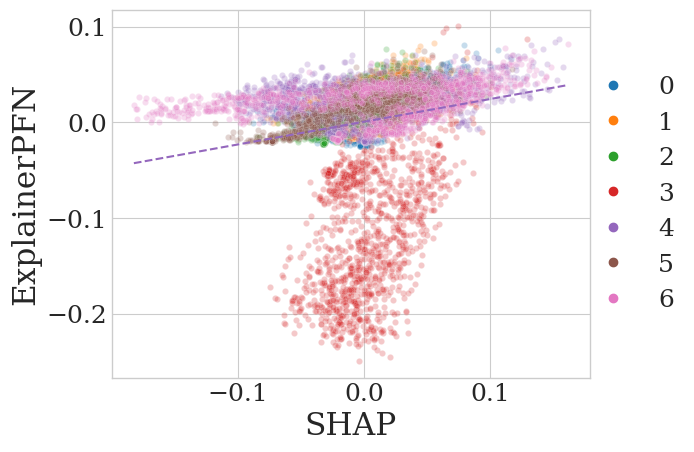

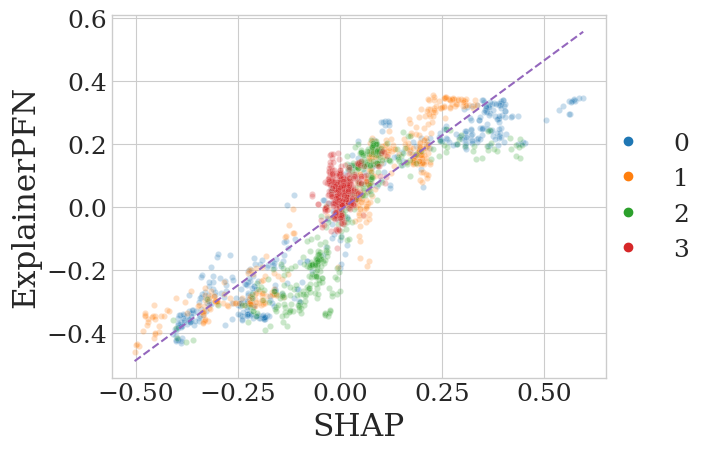

In [3]:
from sklearn.linear_model import LinearRegression
from matplotlib.lines import Line2D
from mlresearch.utils import set_matplotlib_style

set_matplotlib_style(use_latex=False, font_size=18, **{"font.family":"serif"})

# Plot Hepatitis dataset explanations comparison
with open("results_across_datasets_random_forest.pkl", "rb") as f:
    results = pickle.load(f)

for dataset_name in ["ABALONE", "BANKNOTE AUTHENTICATION"]:
    shap_values = results[dataset_name]["shap"]
    exp_corr = results[dataset_name]["explainerpfn_statistical+additive"]

    fig, ax = plt.subplots(figsize=(7.5, 5))

    reg = LinearRegression().fit(shap_values.reshape(-1, 1), exp_corr.reshape(-1, 1))
    x = np.linspace(shap_values.min(), shap_values.max(), 100).reshape(-1, 1)
    lin_values = reg.predict(x)

    for i, col in enumerate(range(shap_values.shape[1])):
        sns.scatterplot(x=shap_values[:, i], y=exp_corr[:, i], label=col, s=20, alpha=0.25, ax=ax)

    # ax = plt.gca()
    orig_handles, orig_labels = ax.get_legend_handles_labels()

    opaque_handles = [
        Line2D([0], [0], marker='o', color=h.get_facecolor()[0], linestyle='',
               markersize=6, alpha=1)
        for h in orig_handles
    ]

    sns.lineplot(x=x.flatten(), y=lin_values.flatten(), color='C4', linestyle='--', ax=ax)

    ax.legend(
        opaque_handles,
        orig_labels,
        title=None,
        bbox_to_anchor=(0.95, 0.5),
        loc='center left',
        ncol=1,  # len(orig_labels),
    )

    plt.xlabel("SHAP")
    plt.ylabel("ExplainerPFN")
    plt.tight_layout()
    plt.savefig(f"{dataset_name.lower()}_shap_vs_explainerpfn.pdf")
    plt.show()

# Time analysis

In [12]:
def get_time_results_table(
    results,
):
    for dataset_name in results:
        time_results = {}
        for key in results[dataset_name]:
            if key.endswith("_time"):
                time_results[key] = results[dataset_name][key]
        results[dataset_name]["time_results"] = time_results
    df = pd.DataFrame(
        {
            dataset_name: results[dataset_name]["time_results"]
            for dataset_name in results
        }
    )
    df.index = df.index.map(lambda x: x.replace("_time", ""))
    df = df.loc[df.index.map(lambda x: x.endswith("n10") or "_" not in x)]
    df.index = df.index.map(lambda x: x.replace("_n10", ""))
    return df

In [13]:
with open("results_across_datasets_mlp.pkl", "rb") as f:
    results_mlp = pickle.load(f)

df1 = get_time_results_table(results_mlp)
df1["Base Model"] = "MLP"

with open("results_across_datasets_random_forest.pkl", "rb") as f:
    results_rf = pickle.load(f)

df2 = get_time_results_table(results)
df2["Base Model"] = "RF"

df = pd.concat([df1, df2], axis=0)
n_cells = summary["Features"] * summary["Observations"]

# Time per 1000 cells
df = df.reset_index(names="Method").set_index(["Base Model", "Method"]) / n_cells * 1000

df = df.mean(axis=1).to_frame().reset_index().pivot(columns="Base Model", index="Method", values=0).map(lambda x: f"{x:.4f}")

# Sort methods
df = df.loc[["shap", "explainerpfn", "tabpfn", "mlp", "rfr"]]
df.to_latex("results_time_per_1000_cells.tex")
df

Base Model,MLP,RF
Method,,
shap,0.2336,8.4983
explainerpfn,0.8759,0.7934
tabpfn,1.5994,2.3620
mlp,0.1055,0.8000
rfr,1.3172,2.0259


# DAG Reconstruction

In [2]:
def get_all_explanations(xai_model, df):
    explanations = {}
    for target_col in tqdm(df.columns): 
        X = df.drop(columns=[target_col]).values
        y = df[target_col].values

        xai = deepcopy(xai_model)
        xai.fit(X, y)
        exp_values = xai.predict(X, y)
        exp_values = xai.apply_correction(y, exp_values - exp_values.mean(axis=0), kind=["statistical", "additive"])
        explanations[target_col] = pd.DataFrame(exp_values, columns=df.drop(columns=[target_col]).columns)
    return explanations

In [3]:
def make_dag_from_explanations(explanations, n_edges=7):
    G = nx.DiGraph()
    edges = []
    for target in explanations:
        exp_df = explanations[target].abs().mean()
        edges.extend([{"source": source, "target": target, "weight": weight} for source, weight in exp_df.items()])

    # Filter edges by number of edges
    all_weights = [edge["weight"] for edge in edges]
    sorted_edges = sorted(edges, key=lambda x: x["weight"], reverse=True)
    edges = sorted_edges[:n_edges]
    for edge in edges:
        G.add_edge(edge["source"], edge["target"], weight=edge["weight"])
    return G

In [4]:
def plot_dag(G, colors=None):
    colors = colors if colors is not None else "#A0CBE2"
    plt.figure(figsize=(4, 4))
    pos = nx.shell_layout(G)
    nx.draw(
        G, pos, with_labels=True, arrows=True, node_size=700, node_color=colors
    )
    edge_labels = nx.get_edge_attributes(G, "weight")
    formatted_edge_labels = {k: f"{v:.2f}" for k, v in edge_labels.items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=formatted_edge_labels)

In [41]:

generator = SyntheticDataGenerator(
    n_dags=[4, 4],
    n_nodes=[2, 3],
    n_features=[6, 7],
    successor_as_target=[True], 
    random_state=random_state
)
params = generator._sample_params()
df, dag = generator._dataset(**params, activations=[identity])
df.drop(columns=df.columns[-1], inplace=True)  # Drop target column
df.columns = df.columns.map(lambda x: x.split("_")[1])
df = df.T.sort_index().T
df

,0,1,2,4,5,6
0,-0.815411,0.815411,-1.079579,-0.480500,-0.709843,0.480500
1,-1.317436,1.317436,-1.194715,0.645725,0.422141,-0.645725
2,0.452889,-0.452889,0.292445,0.990496,1.074701,-0.990496
3,-0.060469,0.060469,-0.976054,0.677670,0.498860,-0.677670
4,-1.372884,1.372884,-1.542231,-1.501839,-1.850393,1.501839
...,...,...,...,...,...,...
1463,0.426654,-0.426654,0.835637,-1.583360,-1.456018,1.583360
1464,-0.556217,0.556217,-0.002916,0.932948,0.956305,-0.932948
1465,-0.096733,0.096733,0.274036,0.568852,0.638536,-0.568852
1466,-0.317141,0.317141,-0.067856,0.028329,0.015416,-0.028329


In [42]:
all_nodes = list(dag.nodes)
nodes_in_data = [int(col) for col in df.columns]
nodes_not_in_data = [node for node in all_nodes if node not in nodes_in_data]
colors = {
    **{node: "#CA9E98" for node in nodes_not_in_data},
    **{node: "#A0CBE2" for node in nodes_in_data}
}
colors = [colors[node] for node in dag.nodes]

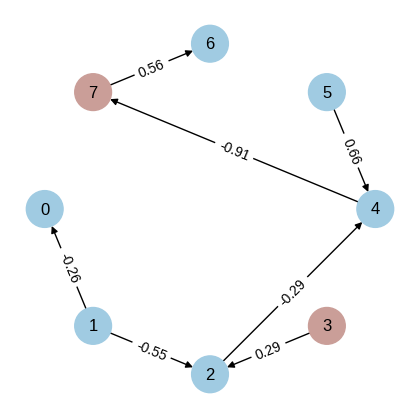

In [43]:
plot_dag(dag, colors=colors)
plt.savefig("dag_ground_truth.pdf")

In [44]:
xai_model = ExplainerPFN(model_path=model_path, random_state=random_state, device=device)
explanations = get_all_explanations(xai_model, df)

  0%|          | 0/6 [00:00<?, ?it/s]

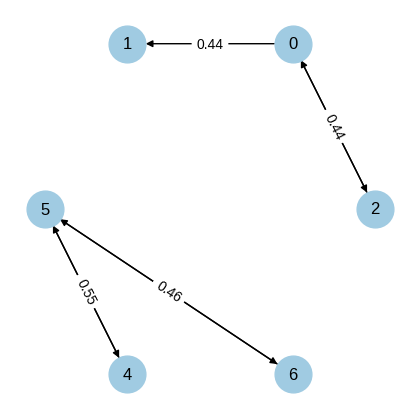

In [51]:
# Plot explanation graph
G_exp = make_dag_from_explanations(explanations, n_edges=7)
plot_dag(G_exp)
plt.savefig("dag_predicted.pdf")

In [10]:
nx.graph_edit_distance(
    dag.to_undirected(), 
    make_dag_from_explanations(explanations, n_edges=7).to_undirected()
)

5.0

In [11]:
# Generate several DAGs and get explanation graphs
xai_model = ExplainerPFN(model_path=model_path, random_state=random_state, device=device)
dags = []
dfs = []
explanations = []
for _ in tqdm(range(50)):
    params = generator._sample_params()
    df, dag = generator._dataset(**params, activations=[identity])
    df.drop(columns=df.columns[-1], inplace=True)  # Drop target column
    df.columns = df.columns.map(lambda x: x.split("_")[1])
    df = df.T.sort_index().T
    dfs.append(df)
    dags.append(dag)
    explanations.append(get_all_explanations(xai_model, df))

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

...

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

In [29]:
max_edges = dfs[0].shape[1] * (dfs[0].shape[1] - 1)
n_edges = np.arange(1, max_edges+1)
all_edit_distances = []
for dag, df, exp_ in tqdm(list(zip(dags, dfs, explanations))):
    edit_distances = [
        nx.graph_edit_distance(
            dag.to_undirected(), 
            make_dag_from_explanations(exp_, n_edges=edges_).to_undirected()
        )
        for edges_ in n_edges
    ]
    all_edit_distances.append(edit_distances)

with open("synthetic_dags_explanations.pkl", "wb") as f:
    pickle.dump((dags, dfs, explanations, all_edit_distances), f)

  0%|          | 0/50 [00:00<?, ?it/s]

In [31]:
dags, dfs, explanations, all_edit_distances = pickle.load(open("synthetic_dags_explanations.pkl", "rb"))

In [32]:
# Generate random weights and measure edit distances
rng = np.random.default_rng(seed=42)
max_edges = dfs[0].shape[1] * (dfs[0].shape[1] - 1)
n_edges = np.arange(1, max_edges+1)
random_edit_distances = []
for dag, _, exp_ in tqdm(list(zip(dags, dfs, explanations))):
    random_exp_ = {
        target: pd.DataFrame(
            rng.uniform(low=0.0, high=1.0, size=df.shape),
            columns=df.columns
        )
        for target, df in exp_.items()
    }
    rand_edit_distances = [
        nx.graph_edit_distance(
            dag.to_undirected(), 
            make_dag_from_explanations(random_exp_, n_edges=edges_).to_undirected()
        )
        for edges_ in n_edges
    ]
    random_edit_distances.append(rand_edit_distances)

with open("random_data_edit_distances.pkl", "wb") as f:
    pickle.dump(random_edit_distances, f)

  0%|          | 0/50 [00:00<?, ?it/s]

In [33]:
with open("random_data_edit_distances.pkl", "rb") as f:
    random_edit_distances = pickle.load(f)

In [34]:
n_edges_gt_list = []
for dag, _, exp_ in tqdm(list(zip(dags, dfs, explanations))):
    n_edges_gt = dag.to_undirected().number_of_edges()
    n_edges_gt_list.append(n_edges_gt)

print("# Edges GT:", np.unique(n_edges_gt_list))

  0%|          | 0/50 [00:00<?, ?it/s]

# Edges GT: [7]


In [35]:
from mlresearch.utils import set_matplotlib_style
set_matplotlib_style(use_latex=False, font_size=18, **{"font.family":"serif"})

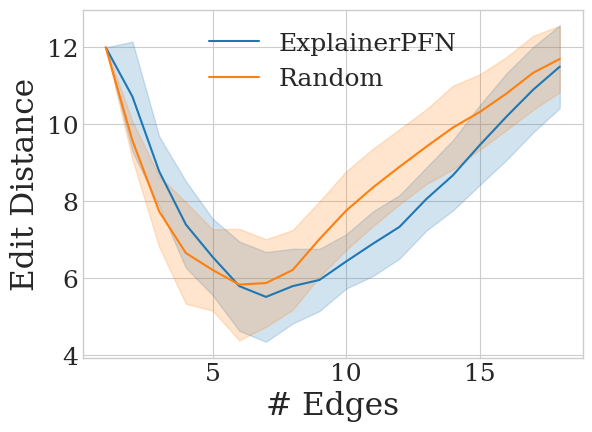

In [52]:
# Plot average edit distances across thresholds (with std shading)
for edit_dist in [all_edit_distances, random_edit_distances]:
    df_distances = pd.DataFrame(edit_dist, columns=n_edges).T
    df_distances["# Edges"] = df_distances.index.rename("# Edges")
    df_distances = df_distances[df_distances["# Edges"] <= 18]
    df_distances = (
        df_distances
        .groupby("# Edges")
        .apply(lambda _df: _df.melt(), include_groups=False)
        .rename(columns={"variable": "DAG", "value": "Edit Distance"})
        .copy()
    )
    df_distances = df_distances.reset_index().drop(columns="level_1")

    sns.lineplot(
        data=df_distances,
        x="# Edges",
        y="Edit Distance",
        errorbar="sd",
        label="ExplainerPFN" if edit_dist is all_edit_distances else "Random",
    )

plt.tight_layout()
plt.savefig("dag_graph_edit_distance.pdf")